In [1]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


Initial guess [-1.8, 1.8], Result: [0.99999508 0.99999014], Value: 2.426114385079562e-11, Success: True, Iterations: 29, Time: 0.0169 sec
Initial guess [2.4, 3], Result: [0.99999554 0.99999106], Value: 1.9935251017332642e-11, Success: True, Iterations: 19, Time: 0.0110 sec
Initial guess [0.05, 0.005], Result: [0.9999961  0.99999218], Value: 1.523917033909588e-11, Success: True, Iterations: 21, Time: 0.0061 sec


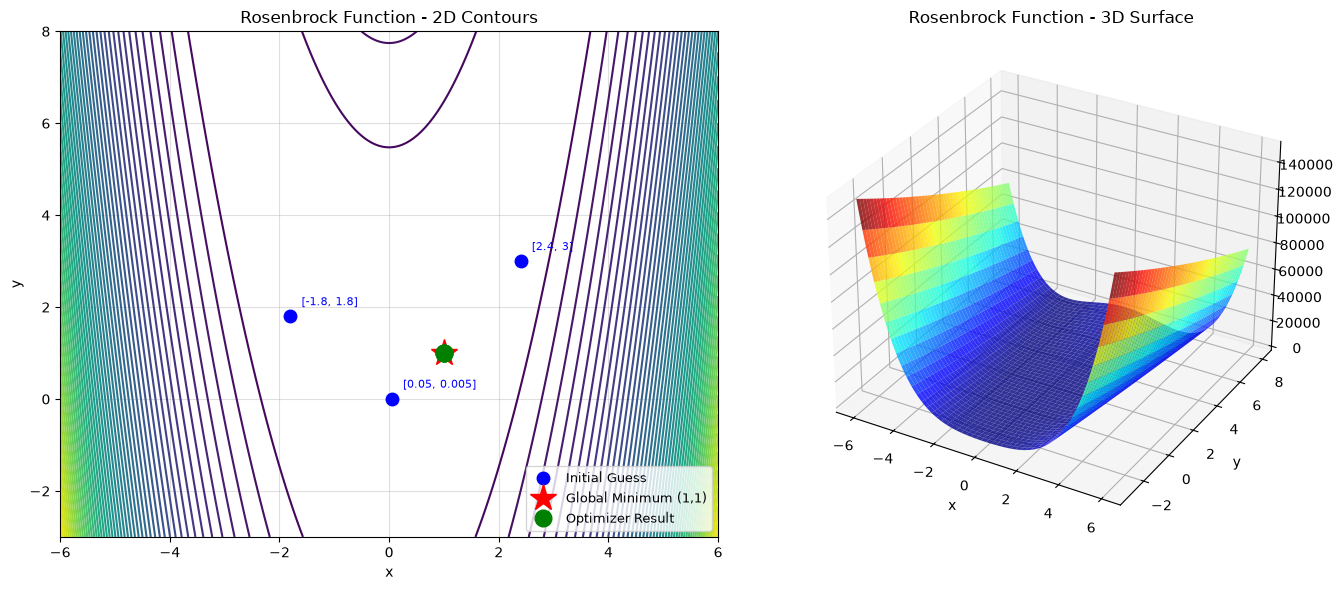

PyGAD initial guess [-1.8, 1.8], Solution: [0.98787226 0.97521488], Value: 0.00019287853535646704, iterations: 2000, Time: 1.1170 sec
PyGAD initial guess [2.4, 3], Solution: [0.99416397 0.98944173], Value: 0.00015064173176752138, iterations: 2000, Time: 1.1456 sec
PyGAD initial guess [0.05, 0.005], Solution: [1.00448209 1.00867025], Value: 2.994970386847223e-05, iterations: 2000, Time: 1.0862 sec


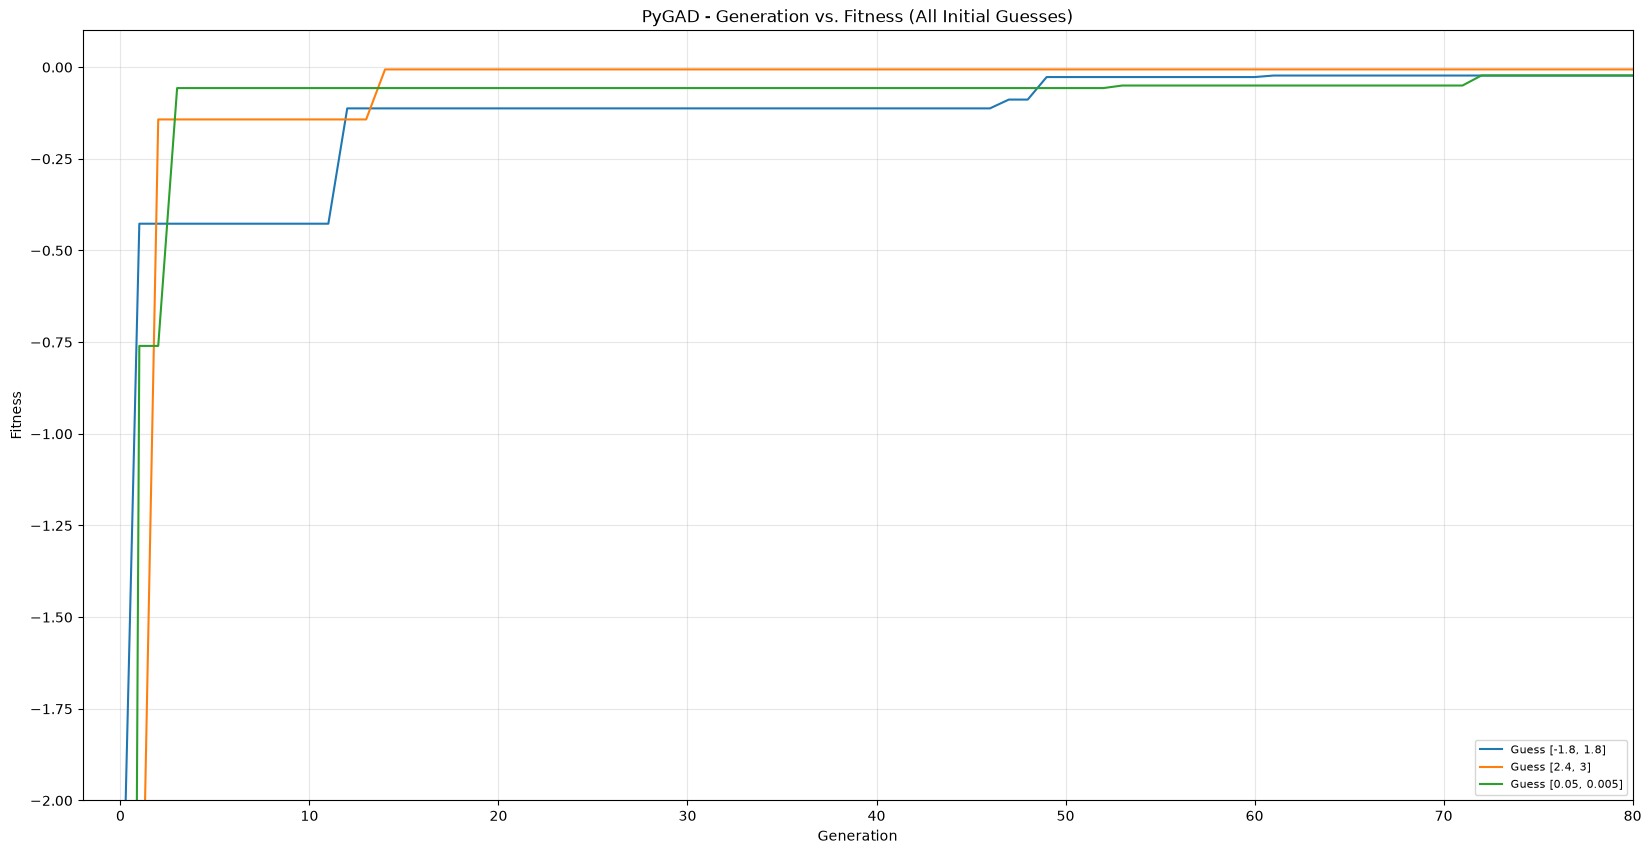

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# ---------------- Run Scipy Optimization FIRST ----------------
scipy_results = []  # (guess, final_point) pairs

init_guesses = [[-1.8, 1.8], [2.4, 3], [0.05, 0.005]]

for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, "
          f"Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")
    scipy_results.append((guess, result.x))

# ---------------- 2D & 3D plots ----------------
x_range = np.linspace(-6, 6, 500)
y_range = np.linspace(-3, 8, 500)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function - 2D Contours")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True, alpha=0.4)

# plot initial guesses 
for i, (guess, final) in enumerate(scipy_results):
    ax1.plot(guess[0], guess[1], 'o', color='blue', markersize=9, zorder=4,
              label='Initial Guess' if i == 0 else "")
    ax1.annotate(f"[{guess[0]}, {guess[1]}]", (guess[0], guess[1]),
                  textcoords="offset points", xytext=(8, 8),
                  fontsize=8, color='blue')

# global minimum (red star) 
ax1.plot(1, 1, '*', color='red', markersize=20, zorder=4,
          label='Global Minimum (1,1)')

# optimizer results (green) 
for i, (guess, final) in enumerate(scipy_results):
    ax1.plot(final[0], final[1], 'o', color='green', markersize=12, zorder=6,
              label='Optimizer Result' if i == 0 else "")

ax1.legend(fontsize=9, loc='lower right')
ax1.set_xlim(-6, 6)
ax1.set_ylim(-3, 8)

# --- 3D surface ---
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function - 3D Surface")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

# ---------------- PyGAD Optimization ----------------
# ---------------- PyGAD Optimization ----------------
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution)  # pygad maximizes, so negate

elapsed_time = []
fitness_histories = []  # store (guess, fitness_history) for each run

for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low': -2, 'high': 2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {rosenbrock(solution)}, "
          f"iterations: {iters}, Time: {elapsed_time:.4f} sec")

    # store this run's fitness-per-generation history
    fitness_histories.append((guess, ga_instance.best_solutions_fitness))

# ---------------- Plot ALL guesses' fitness curves together ----------------
plt.figure(figsize=(20, 10))
for guess, history in fitness_histories:
    plt.plot(history, label=f"Guess {guess}")

plt.title("PyGAD - Generation vs. Fitness (All Initial Guesses)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# zoomed-in view
plt.xlim(-2, 80)
plt.ylim(-2, 0.1)

plt.show()

1 Answer

i) BFGS lands on the same solution no matter where we start, aside from tiny numerical error. That solution is the global minimum of the function.

ii) PyGAD also settles near (1, 1) across all initial guesses, so it likewise locates the global minimum. It gets there differently, though — it takes hundreds of generations, and its fitness curve rises in steps as improved candidates are found by chance, unlike BFGS's quick, steady gradient-based path.

iii) Comparison

1. Iterations: BFGS reaches the solution in roughly 20-40 steps since it follows the gradient directly. PyGAD requires far more, typically hundreds of generations because it relies on random search rather than directional information.

2. Time: BFGS runs in milliseconds. PyGAD takes noticeably longer, on the order of seconds, since each generation evaluates an entire population of candidates.

3. Accuracy: Both approaches arrive at the same global minimum regardless of starting point, but BFGS's result is precise to many decimal places, whereas PyGAD's is somewhat coarser and fluctuates slightly between runs.


PART 1: SciPy Optimization & Annotated Visualization
Initial guess [1, 0.005], Result: [3.         1.99999998], Value: 7.175589324611337e-15, Success: True, Iterations: 8, Time: 0.0060 sec
Initial guess [-1, 0.9], Result: [-2.80511809  3.13131254], Value: 2.2706142817551132e-14, Success: True, Iterations: 7, Time: 0.0040 sec
Initial guess [0, 0.5], Result: [2.99999995 2.00000003], Value: 7.736661180169729e-14, Success: True, Iterations: 11, Time: 0.0041 sec


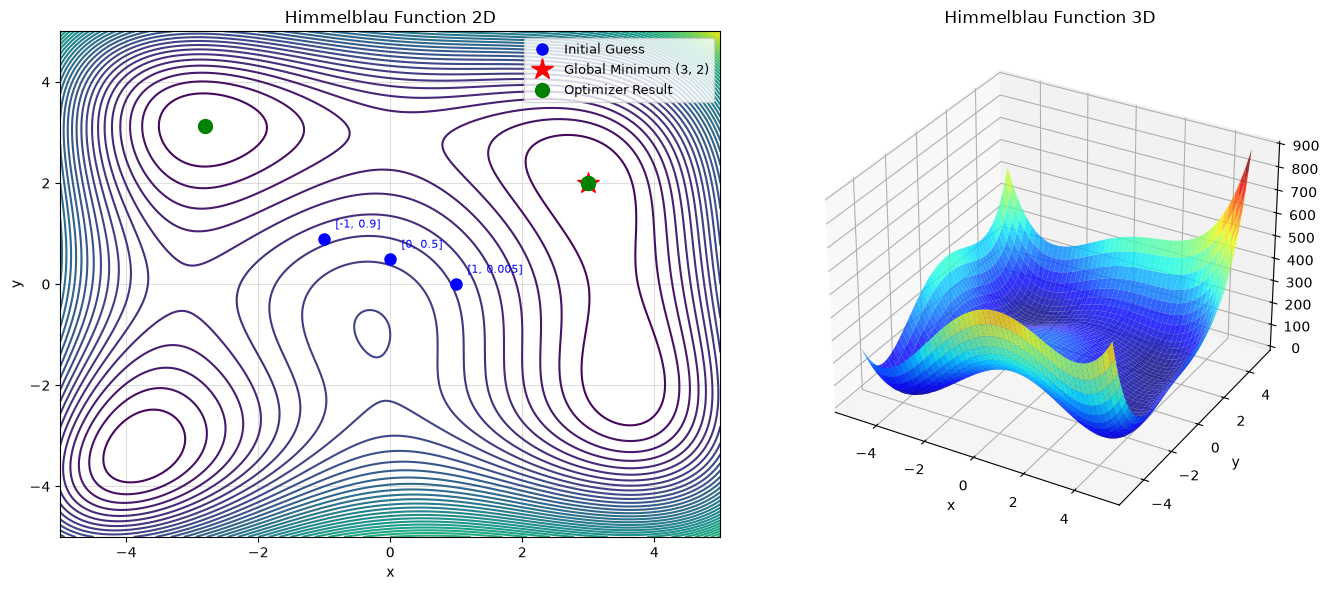


PART 2: PyGAD (Genetic Algorithm)
PyGAD Guess [1, 0.005] -> Solution: [3.002515, 2.000080], f(x)=2.38e-04, Iter=300, Time=0.2574s
PyGAD Guess [-1, 0.9] -> Solution: [3.584262, -1.846457], f(x)=4.03e-05, Iter=300, Time=0.2720s
PyGAD Guess [0, 0.5] -> Solution: [3.580188, -1.847031], f(x)=9.26e-04, Iter=300, Time=0.2635s


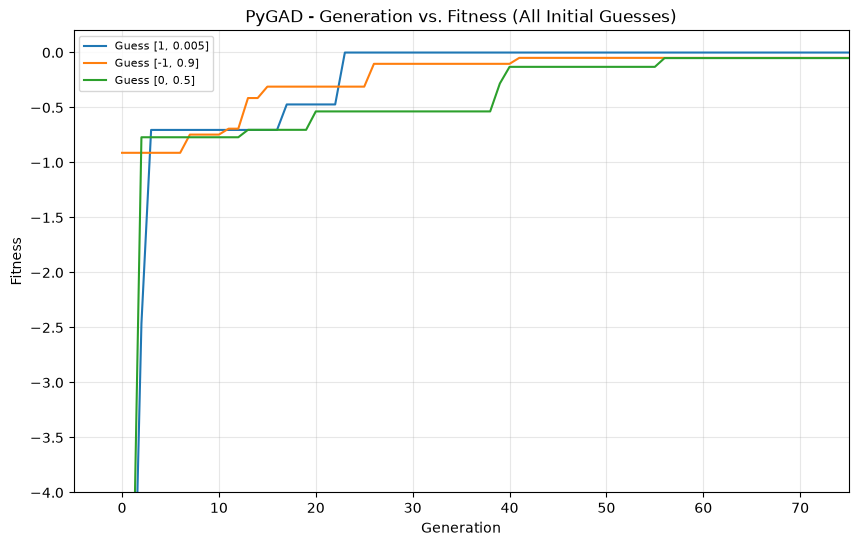


PART 3: Comparison — BFGS vs PyGAD
Guess           BFGS x,y                  GA x,y                    BFGS iter  GA iter  BFGS time  GA time
[1, 0.005]      [3.0000,2.0000]    [3.0025,2.0001]    8          300      0.0060     0.2574
[-1, 0.9]       [-2.8051,3.1313]    [3.5843,-1.8465]    7          300      0.0040     0.2720
[0, 0.5]        [3.0000,2.0000]    [3.5802,-1.8470]    11         300      0.0041     0.2635

Avg BFGS time: 0.0047s | Avg BFGS iterations: 8.7
Avg GA time:   0.2643s | Avg GA iterations:   300.0


In [4]:
def himmelblau(x):
  x = np.asarray(x)
  return (x[0] ** 2 + x[1] - 11) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2


init_guesses = [[1, 0.005], [-1, 0.9], [0, 0.5]]
GLOBAL_MIN = (3,2)

# ============================================================
# PART 1: SciPy Optimization & Annotated Visualization
# ============================================================
scipy_results = []
scipy_times = []
scipy_iters = []

print('\n' + '=' * 70)
print('PART 1: SciPy Optimization & Annotated Visualization')
print('=' * 70)

for guess in init_guesses:
  start_time = time.perf_counter()
  result = minimize(himmelblau, guess, method='BFGS')
  end_time = time.perf_counter()

  elapsed_time = end_time - start_time
  scipy_results.append((guess, result.x))
  scipy_times.append(elapsed_time)
  scipy_iters.append(result.nit)

  print(
      f"Initial guess {guess}, Result: {result.x}, Value: {result.fun},"
      f" Success: {result.success}, Iterations: {result.nit}, Time:"
      f" {elapsed_time:.4f} sec"
  )

# 2D (-5 to 5 domain) & 3D Plots with Annotations
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True, alpha=0.4)

# Plot initial guesses and annotations
for i, (guess, final) in enumerate(scipy_results):
  ax1.plot(
      guess[0],
      guess[1],
      'o',
      color='blue',
      markersize=8,
      zorder=4,
      label='Initial Guess' if i == 0 else '',
  )
  ax1.annotate(
      f'[{guess[0]}, {guess[1]}]',
      (guess[0], guess[1]),
      textcoords='offset points',
      xytext=(8, 8),
      fontsize=8,
      color='blue',
  )

# Plot global minimum marker
ax1.plot(
    GLOBAL_MIN[0],
    GLOBAL_MIN[1],
    '*',
    color='red',
    markersize=16,
    zorder=4,
    label=f'Global Minimum {GLOBAL_MIN}',
)

# Plot optimizer end points
for i, (guess, final) in enumerate(scipy_results):
  ax1.plot(
      final[0],
      final[1],
      'o',
      color='green',
      markersize=10,
      zorder=6,
      label='Optimizer Result' if i == 0 else '',
  )

ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)

# 3D Surface Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()


# ============================================================
# PART 2: PyGAD (Genetic Algorithm)
# ============================================================
def fitness_func2(ga_instance, solution, solution_idx):
  return -himmelblau(solution)


print('\n' + '=' * 70)
print('PART 2: PyGAD (Genetic Algorithm)')
print('=' * 70)

ga_results = []
ga_times = []
ga_iters = []
fitness_histories = []

for guess in init_guesses:
  start_time = time.perf_counter()
  ga_instance = pygad.GA(
      num_generations=300,
      sol_per_pop=30,
      num_genes=2,
      num_parents_mating=12,
      fitness_func=fitness_func2,
      init_range_low=-5,
      init_range_high=5,
      gene_space={'low': -5, 'high': 5},
  )
  ga_instance.run()
  solution, solution_fitness, _ = ga_instance.best_solution()
  iters = ga_instance.generations_completed
  end_time = time.perf_counter()
  elapsed_time = end_time - start_time

  ga_results.append((guess, solution))
  ga_times.append(elapsed_time)
  ga_iters.append(iters)
  fitness_histories.append((guess, ga_instance.best_solutions_fitness))

  print(
      f'PyGAD Guess {guess} -> Solution: [{solution[0]:.6f}, {solution[1]:.6f}],'
      f' f(x)={himmelblau(solution):.2e}, Iter={iters},'
      f' Time={elapsed_time:.4f}s'
  )

# Separate Fitness vs Generation Plot for PyGAD
plt.figure(figsize=(10, 6))
for guess, history in fitness_histories:
  plt.plot(history, label=f'Guess {guess}')

plt.title('PyGAD - Generation vs. Fitness (All Initial Guesses)')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.xlim(-5, 75)
plt.ylim(-4, 0.2)
plt.show()

# ============================================================
# PART 3: Comparison — BFGS vs PyGAD
# ============================================================
print('\n' + '=' * 70)
print('PART 3: Comparison — BFGS vs PyGAD')
print('=' * 70)
print(
    f"{'Guess':<16}{'BFGS x,y':<26}{'GA x,y':<26}{'BFGS iter':<11}{'GA iter':<9}{'BFGS time':<11}{'GA time'}"
)
for i, guess in enumerate(init_guesses):
  bx, by = scipy_results[i][1]
  gx, gy = ga_results[i][1]
  print(
      f"{str(guess):<16}[{bx:.4f},{by:.4f}]{'':<4}[{gx:.4f},{gy:.4f}]{'':<4}"
      f"{scipy_iters[i]:<11}{ga_iters[i]:<9}{scipy_times[i]:<11.4f}{ga_times[i]:.4f}"
  )

print(
    f'\nAvg BFGS time: {np.mean(scipy_times):.4f}s | Avg BFGS iterations:'
    f' {np.mean(scipy_iters):.1f}'
)
print(
    f'Avg GA time:   {np.mean(ga_times):.4f}s | Avg GA iterations:  '
    f' {np.mean(ga_iters):.1f}'
)

It is actual Himmelblau function



PART 1: scipy.optimize (BFGS)
Guess [1, 0.005] -> Result: [-1.000000, -0.000000], f(x)=3.59e-16, Success=True, Iter=6, Time=0.0038s
Guess [-1, 0.9] -> Result: [-1.000000, -0.000000], f(x)=5.69e-13, Success=True, Iter=9, Time=0.0049s
Guess [0, 0.5] -> Result: [-1.000000, 0.000000], f(x)=6.73e-15, Success=True, Iter=9, Time=0.0053s


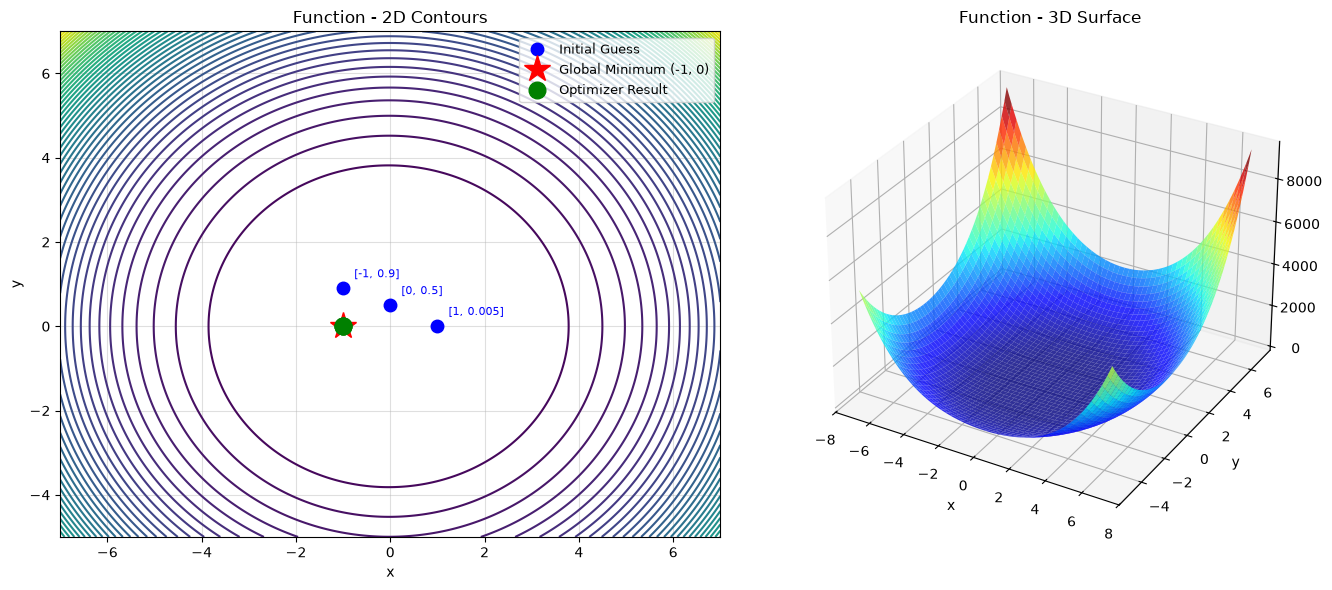


PART 2: PyGAD (Genetic Algorithm)
Guess [1, 0.005] -> Solution: [-0.988174, 0.003972], f(x)=7.08e-04, Iter=300, Time=0.2787s
Guess [-1, 0.9] -> Solution: [-1.010002, -0.003619], f(x)=5.18e-04, Iter=300, Time=0.2692s
Guess [0, 0.5] -> Solution: [-1.006691, 0.001828], f(x)=2.28e-04, Iter=300, Time=0.2572s


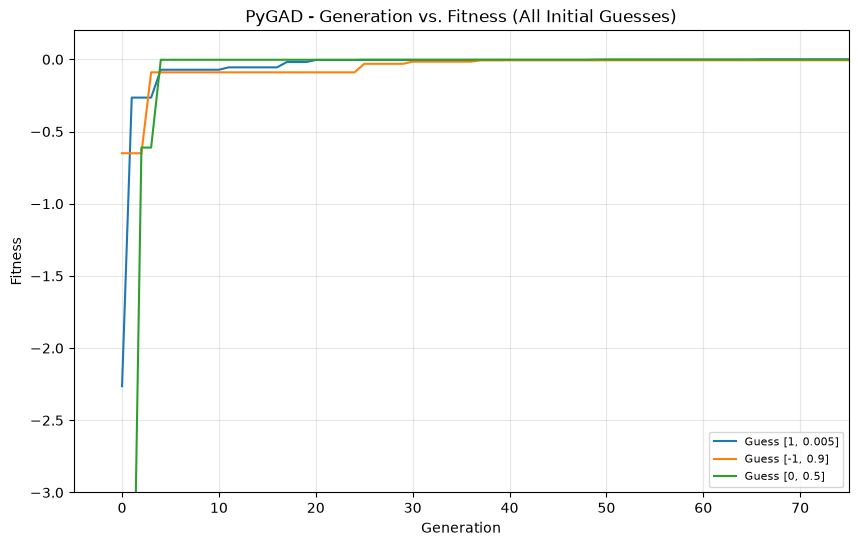


PART 3: Comparison — BFGS vs PyGAD
Guess           BFGS x,y                  GA x,y                    BFGS iter  GA iter  BFGS time  GA time
[1, 0.005]      [-1.0000,-0.0000]    [-0.9882,0.0040]    6          300      0.0038     0.2787
[-1, 0.9]       [-1.0000,-0.0000]    [-1.0100,-0.0036]    9          300      0.0049     0.2692
[0, 0.5]        [-1.0000,0.0000]    [-1.0067,0.0018]    9          300      0.0053     0.2572

Avg BFGS time: 0.0047s | Avg BFGS iterations: 8.0
Avg GA time: 0.2684s | Avg GA iterations: 300.0


In [5]:
def function(x):
    x = np.asarray(x)
    return (x[0]**2 + x[1]**2 - 1)**2 + (x[0] + 1)**2 + x[1]**2

init_guesses = [[1, 0.005], [-1, 0.9], [0, 0.5]]

# global minimum for this function is at (-1, 0), f=0
GLOBAL_MIN = (-1, 0)

# ============================================================
# PART 1: scipy.optimize (BFGS)
# ============================================================
scipy_results = []
scipy_times = []
scipy_iters = []

print("="*70)
print("PART 1: scipy.optimize (BFGS)")
print("="*70)

for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(function, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    scipy_results.append((guess, result.x))
    scipy_times.append(elapsed_time)
    scipy_iters.append(result.nit)

    print(f"Guess {guess} -> Result: [{result.x[0]:.6f}, {result.x[1]:.6f}], "
          f"f(x)={result.fun:.2e}, Success={result.success}, "
          f"Iter={result.nit}, Time={elapsed_time:.4f}s")

# ---- 2D & 3D visualization ----
x_range = np.linspace(-7, 7, 400)
y_range = np.linspace(-5, 7, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = function([X, Y])

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Function - 2D Contours")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True, alpha=0.4)

for i, (guess, final) in enumerate(scipy_results):
    ax1.plot(guess[0], guess[1], 'o', color='blue', markersize=9, zorder=4,
              label='Initial Guess' if i == 0 else "")
    ax1.annotate(f"[{guess[0]}, {guess[1]}]", (guess[0], guess[1]),
                  textcoords="offset points", xytext=(8, 8),
                  fontsize=8, color='blue')

ax1.plot(GLOBAL_MIN[0], GLOBAL_MIN[1], '*', color='red', markersize=20, zorder=4,
          label=f'Global Minimum {GLOBAL_MIN}')

for i, (guess, final) in enumerate(scipy_results):
    ax1.plot(final[0], final[1], 'o', color='green', markersize=12, zorder=6,
              label='Optimizer Result' if i == 0 else "")

ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(-7, 7)
ax1.set_ylim(-5, 7)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Function - 3D Surface")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

# ============================================================
# PART 2: PyGAD (Genetic Algorithm)
# ============================================================
def fitness_func2(ga_instance, solution, solution_idx):
    return -function(solution)

print("\n" + "="*70)
print("PART 2: PyGAD (Genetic Algorithm)")
print("="*70)

ga_results = []
ga_times = []
ga_iters = []
fitness_histories = []

for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low': -5, 'high': 5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    ga_results.append((guess, solution))
    ga_times.append(elapsed_time)
    ga_iters.append(iters)
    fitness_histories.append((guess, ga_instance.best_solutions_fitness))

    print(f"Guess {guess} -> Solution: [{solution[0]:.6f}, {solution[1]:.6f}], "
          f"f(x)={function(solution):.2e}, Iter={iters}, Time={elapsed_time:.4f}s")

# ---- Fitness vs generation, all guesses ----
plt.figure(figsize=(10, 6))
for guess, history in fitness_histories:
    plt.plot(history, label=f"Guess {guess}")

plt.title("PyGAD - Generation vs. Fitness (All Initial Guesses)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.xlim(-5, 75)
plt.ylim(-3, 0.2)
plt.show()

# ============================================================
# PART 3: Comparison
# ============================================================
print("\n" + "="*70)
print("PART 3: Comparison — BFGS vs PyGAD")
print("="*70)
print(f"{'Guess':<16}{'BFGS x,y':<26}{'GA x,y':<26}{'BFGS iter':<11}{'GA iter':<9}{'BFGS time':<11}{'GA time'}")
for i, guess in enumerate(init_guesses):
    bx, by = scipy_results[i][1]
    gx, gy = ga_results[i][1]
    print(f"{str(guess):<16}[{bx:.4f},{by:.4f}]{'':<4}[{gx:.4f},{gy:.4f}]{'':<4}"
          f"{scipy_iters[i]:<11}{ga_iters[i]:<9}{scipy_times[i]:<11.4f}{ga_times[i]:.4f}")

print(f"\nAvg BFGS time: {np.mean(scipy_times):.4f}s | Avg BFGS iterations: {np.mean(scipy_iters):.1f}")
print(f"Avg GA time: {np.mean(ga_times):.4f}s | Avg GA iterations: {np.mean(ga_iters):.1f}")

2 Answer

i) Regardless of the starting point, BFGS always lands on the same solution, (x, y) = (−1, 0), where f(x, y) = 0. This function has a single basin, no competing local minima, so every initial guess is pulled toward that one global optimum; only the number of steps needed changes with starting distance.

ii) PyGAD arrives at essentially the same point, (-1, 0), across all three starting guesses, confirming it also locates the global minimum. Its path there looks very different from BFGS's, though: instead of a smooth, gradient-driven descent, the fitness curve improves in discrete jumps as mutation and crossover happen to produce better candidates, and it needs many more generations to close in on the optimum.

iii) Comparison

1. Iterations: BFGS converges quickly on the order of 5–15 steps for this function, since each step moves directly along the gradient. PyGAD needs substantially more (often in the hundreds of generations), because it explores through random variation rather than following derivative information.

2. Runtime: BFGS finishes in a fraction of a second. PyGAD takes noticeably longer, since it must evaluate an entire population of candidate solutions at every generation rather than a single point.

3. Precision: Both methods ultimately identify the same global minimum, but BFGS's result is far more exact (accurate to many decimal places), while PyGAD's is coarser and can shift slightly from run to run due to its stochastic nature.
